C:\Users\josdk\AppData\Roaming\Python\Python312\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 54284 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:54287' processes=4 threads=12, memory=7.74 GiB>

Summary Statistics:
            Car_ID          Year         Price       Mileage     Engine_CC  \
count  10000.00000  10000.000000  1.000000e+04  10000.000000  10000.000000   
mean    5000.50000   2019.543800  1.946064e+06     19.967300   1542.070000   
std     2886.89568      2.877553  8.837945e+05      5.778583    557.487394   
min        1.00000   2015.000000  4.000000e+05     10.000000    800.000000   
25%     2500.75000   2017.000000  1.180000e+06     14.900000   1000.000000   
50%     5000.50000   2020.000000  1.950000e+06     20.000000   1500.000000   
75%     7500.25000   2022.000000  2.700000e+06     25.000000   2000.000000   
max    10000.00000   2024.000000  3.500000e+06     30.000000   2500.000000   

       Seating_Capacity  Service_Cost  
count      10000.000000  10000.000000  
mean           5.515400  14969.130000  
std            1.121556   5777.753741  
min            4.000000   5000.000000  
25

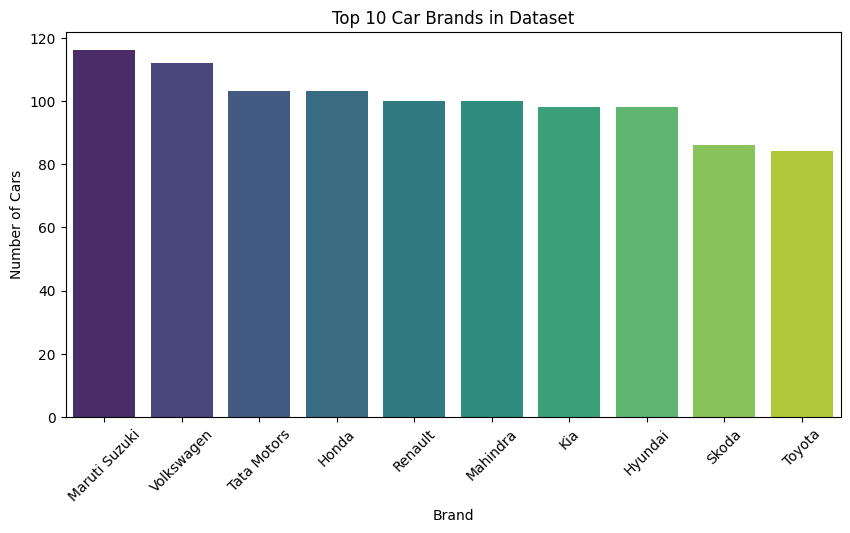

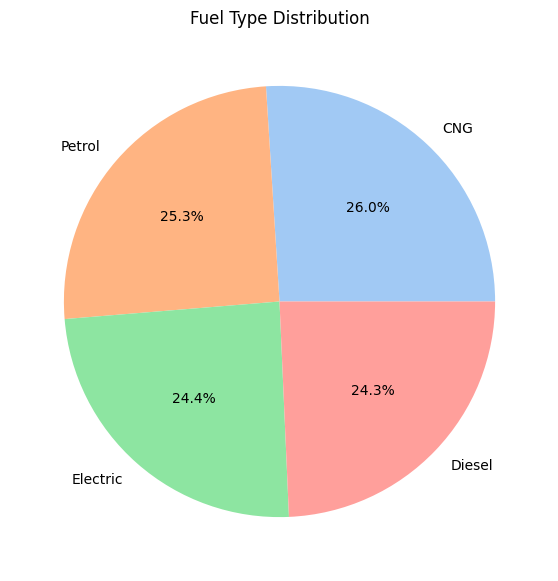

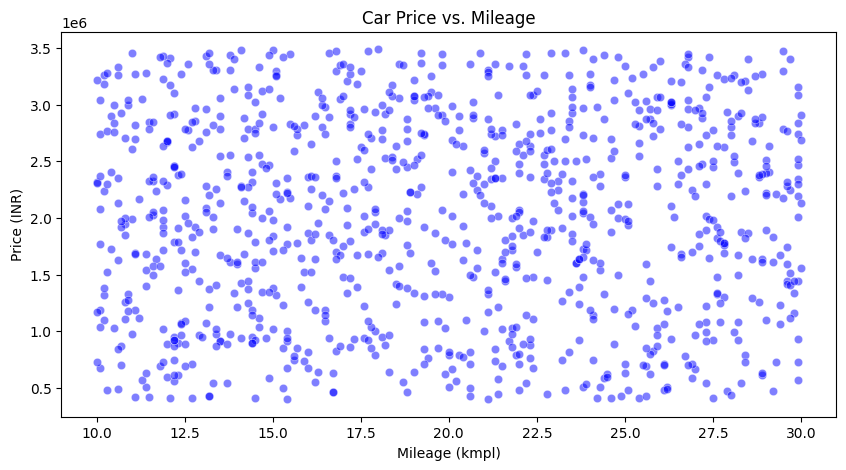

In [2]:
from dask.distributed import Client
import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns

def main():
    # Start a Dask Client for distributed execution
    client = Client()
    print(client)  # Displays cluster information

    # Load dataset
    file_path = "car_dataset_india.csv"
    df = dd.read_csv(file_path, blocksize="50MB")  # Process in 50MB chunks

    # Persist DataFrame for better performance
    df = df.persist()

    # Compute basic statistics
    print("\nSummary Statistics:")
    print(df.describe().compute())

    # Average price by fuel type
    avg_price_fuel = df.groupby('Fuel_Type')['Price'].mean().compute()
    print("\nAverage Car Price by Fuel Type:")
    print(avg_price_fuel)

    # Filter high mileage cars
    high_mileage_cars = df[df['Mileage'] > 20].persist()
    print("\nHigh mileage cars (Mileage > 20 kmpl):")
    print(high_mileage_cars.head())

    # Save results
    high_mileage_cars.to_csv("high_mileage_cars.csv", index=False, single_file=True)
    print("\nFiltered high mileage cars saved successfully.")

    # Convert Dask DataFrame to Pandas for visualization
    df_pd = df.sample(frac=0.1).compute()  # Sample 10% for quick visualization

    # Bar Chart: Number of Cars per Brand
    plt.figure(figsize=(10, 5))
    brand_counts = df_pd["Brand"].value_counts().head(10)  # Top 10 brands
    sns.barplot(x=brand_counts.index, y=brand_counts.values, hue=brand_counts.index, palette="viridis", legend=False)
    plt.xticks(rotation=45)
    plt.xlabel("Brand")
    plt.ylabel("Number of Cars")
    plt.title("Top 10 Car Brands in Dataset")
    plt.show()

    # Pie Chart: Fuel Type Distribution
    plt.figure(figsize=(7, 7))
    fuel_counts = df_pd["Fuel_Type"].value_counts()
    plt.pie(fuel_counts, labels=fuel_counts.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"))
    plt.title("Fuel Type Distribution")
    plt.show()

    # Scatter Plot: Price vs. Mileage
    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=df_pd["Mileage"], y=df_pd["Price"], alpha=0.5, color="blue")
    plt.xlabel("Mileage (kmpl)")
    plt.ylabel("Price (INR)")
    plt.title("Car Price vs. Mileage")
    plt.show()

if __name__ == "__main__":
    main()
